In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split


In [12]:
# 1. Load data
df = pd.read_csv("marketing_campaign.csv",sep="\t")


In [13]:
# 2. Quick info before cleaning
print("Shape before cleaning:", df.shape)
print(df.isna().sum())

Shape before cleaning: (2240, 29)
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


In [14]:
# 3. Drop duplicate rows (if any)
df = df.drop_duplicates()

In [15]:
# 4. Handle missing values
df = df.dropna(subset=["Income"])  # or use median instead
# df["Income"] = df["Income"].fillna(df["Income"].median())

In [16]:
# 5. Convert data types
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")

numeric_cols = [
    "Year_Birth", "Income", "Kidhome", "Teenhome", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "AcceptedCmp1", "AcceptedCmp2",
    "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain",
    "Z_CostContact", "Z_Revenue", "Response"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(0)

In [17]:
# Feature engineering
current_year = 2026
df["Age"] = current_year - df["Year_Birth"]
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds"
]
df["TotalSpent"] = df[spend_cols].sum(axis=1)

In [18]:
# Remove simple outliers
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]
df = df[df["Income"] > 0]

df = df.reset_index(drop=True)

print("Shape after cleaning:", df.shape)
df.head()

Shape after cleaning: (2213, 32)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,TotalChildren,TotalSpent
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,3,11,1,69,0,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,3,11,0,72,2,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,3,11,0,61,0,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,3,11,0,42,1,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,3,11,0,45,1,422


In [19]:
print("Shape before cleaning:", df.shape)
print(df.isna().sum())

Shape before cleaning: (2213, 32)
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
Age                    0
TotalChildren          0
TotalSpent             0
dtype: int64


In [21]:
df.Marital_Status.unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

# Load data (tab-separated)
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Basic cleaning / feature engineering (short version)
df = df.dropna(subset=["Income"])  # drop rows with missing income
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")

numeric_cols = [
    "Year_Birth", "Income", "Kidhome", "Teenhome", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "AcceptedCmp1", "AcceptedCmp2",
    "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain",
    "Z_CostContact", "Z_Revenue", "Response"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_cols] = df[numeric_cols].fillna(0)

current_year = 2026
df["Age"] = current_year - df["Year_Birth"]

spend_cols = [
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds"
]
df["TotalSpent"] = df[spend_cols].sum(axis=1)

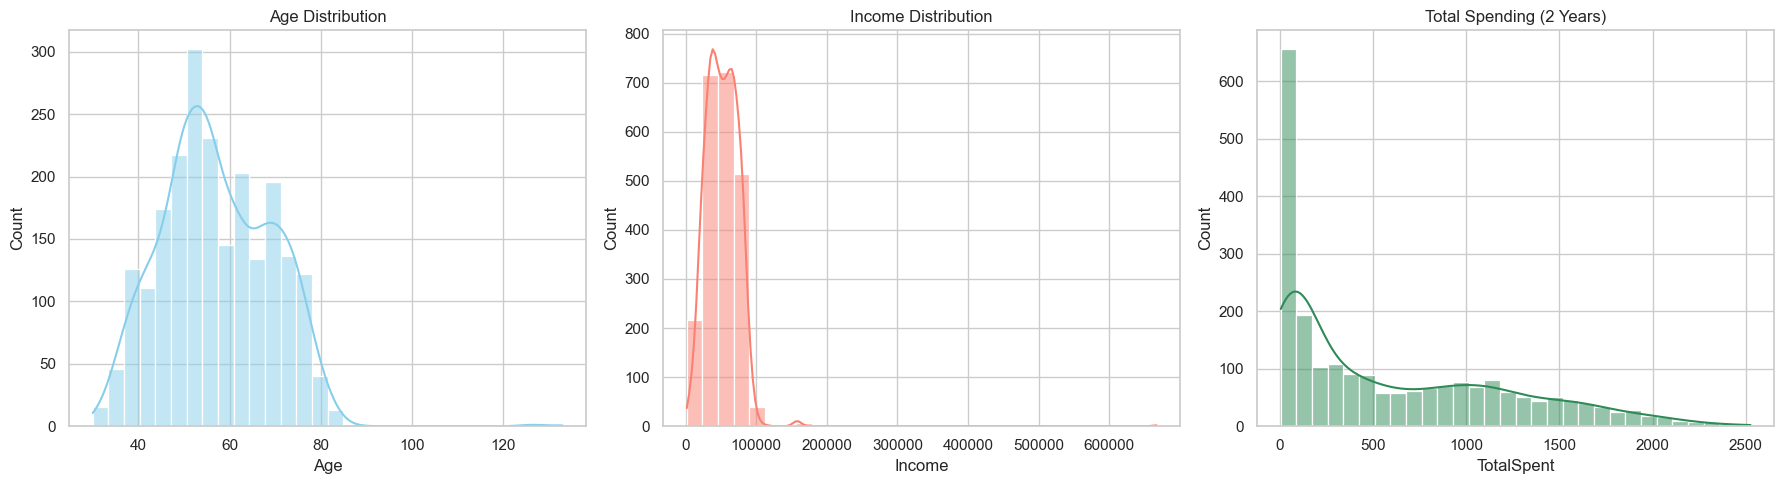

In [15]:
# Histograms: Age, Income, TotalSpent
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Age"], bins=30, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Age Distribution")

sns.histplot(df["Income"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Income Distribution")

sns.histplot(df["TotalSpent"], bins=30, kde=True, ax=axes[2], color="seagreen")
axes[2].set_title("Total Spending (2 Years)")

plt.tight_layout()
plt.show()

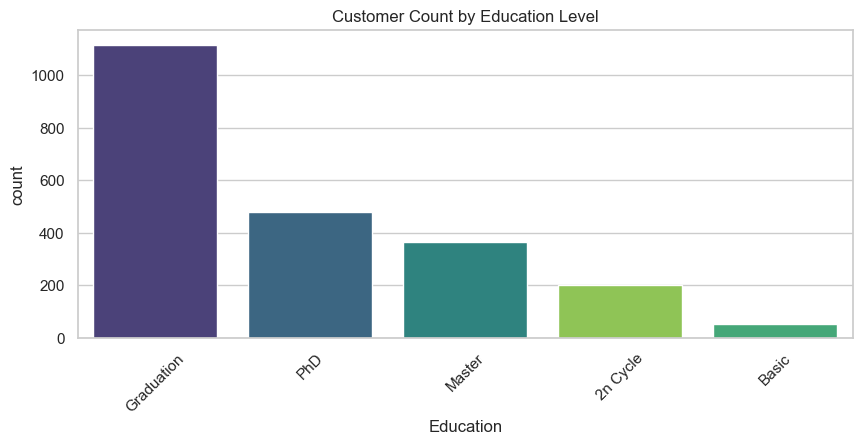

In [20]:
# Bar plots: Education and Marital Status
plt.figure(figsize=(10,4))
sns.countplot(
    data=df,
    x="Education",
    hue="Education",
    order=df["Education"].value_counts().index,
    palette="viridis",
    legend=False
)
plt.xticks(rotation=45)
plt.title("Customer Count by Education Level")
plt.show()

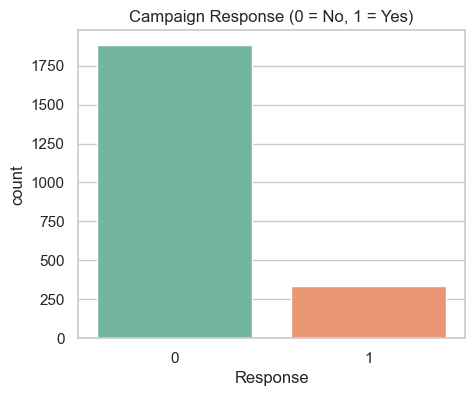

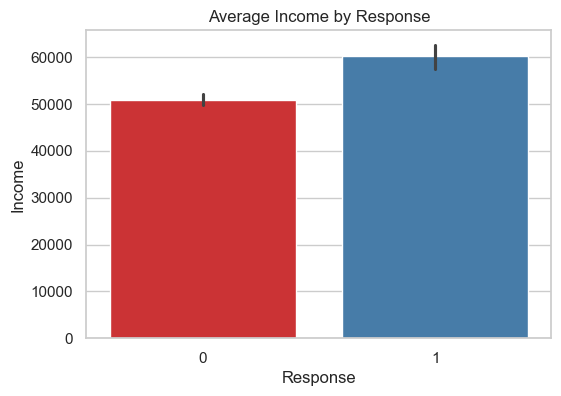

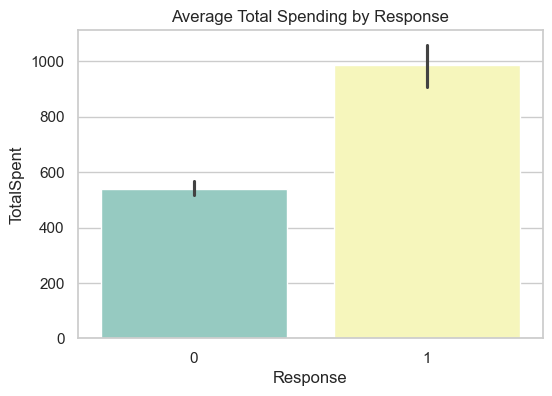

In [21]:
#Response vs. other variables
# Response vs. other variables

# 1) Response count
plt.figure(figsize=(5,4))
sns.countplot(
    data=df,
    x="Response",
    hue="Response",
    palette="Set2",
    legend=False
)
plt.title("Campaign Response (0 = No, 1 = Yes)")
plt.show()

# 2) Average income by response
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="Response",
    y="Income",
    hue="Response",
    estimator=np.mean,
    palette="Set1",
    legend=False
)
plt.title("Average Income by Response")
plt.show()

# 3) Average total spent by response
plt.figure(figsize=(6,4))
sns.barplot(
    data=df,
    x="Response",
    y="TotalSpent",
    hue="Response",
    estimator=np.mean,
    palette="Set3",
    legend=False
)
plt.title("Average Total Spending by Response")
plt.show()

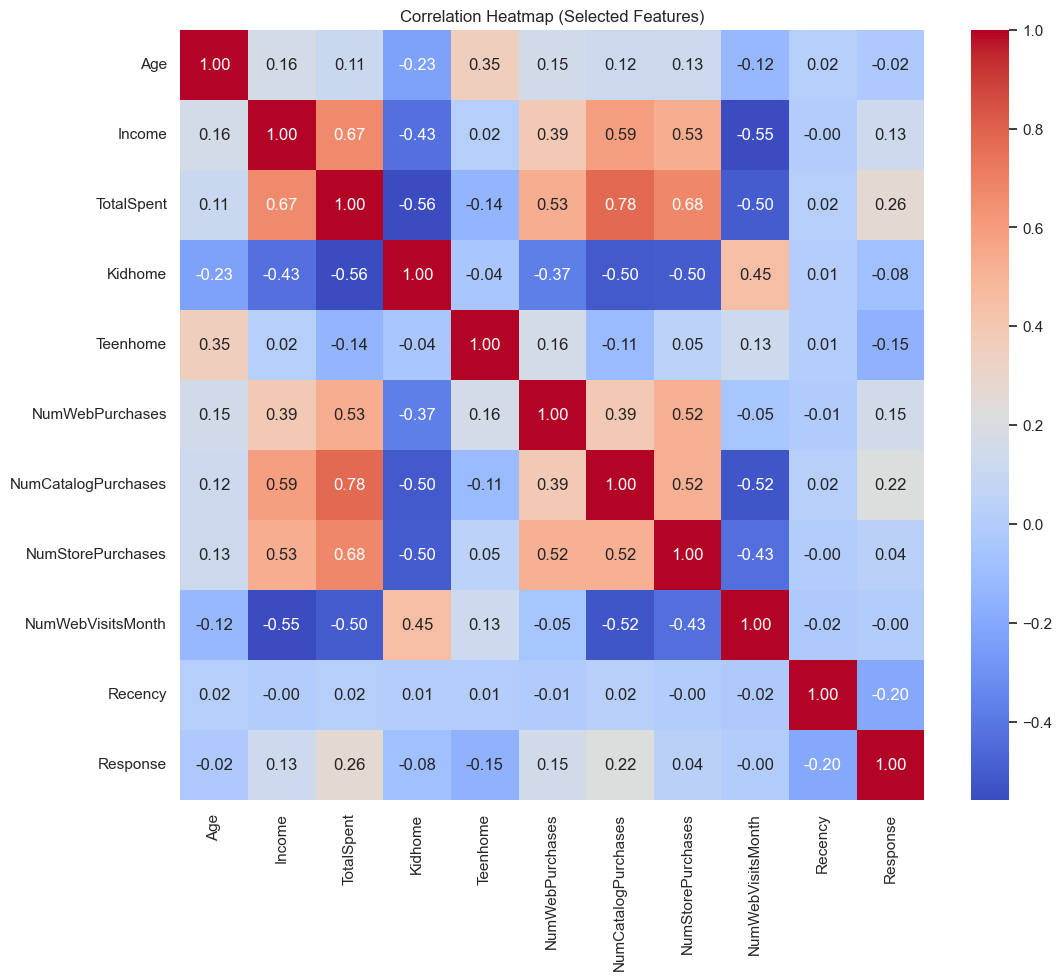

In [19]:
#Correlation heaplt.figure(figsize=(12,10))
plt.figure(figsize=(12,10))
corr = df[["Age", "Income", "TotalSpent", "Kidhome", "Teenhome",
           "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
           "NumWebVisitsMonth", "Recency", "Response"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Selected Features)")
plt.show()


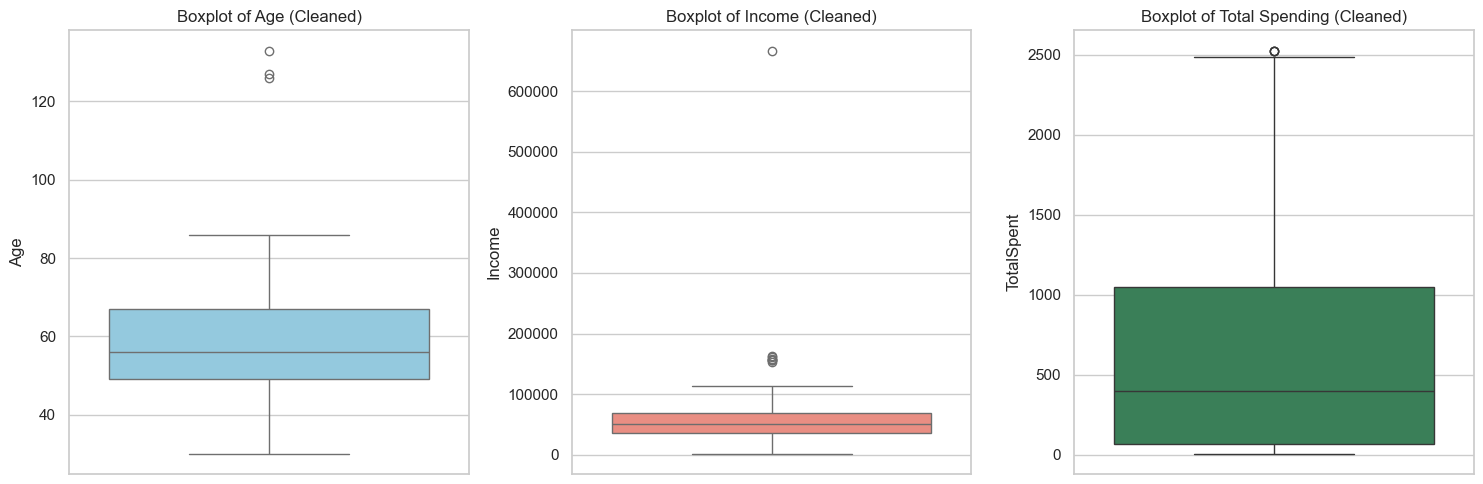

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Boxplots for key numeric variables after cleaning
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df["Age"], color="skyblue")
plt.title("Boxplot of Age (Cleaned)")

plt.subplot(1, 3, 2)
sns.boxplot(y=df["Income"], color="salmon")
plt.title("Boxplot of Income (Cleaned)")

plt.subplot(1, 3, 3)
sns.boxplot(y=df["TotalSpent"], color="seagreen")
plt.title("Boxplot of Total Spending (Cleaned)")

plt.tight_layout()
plt.show()

In [26]:
def remove_outliers_iqr(data, cols):
    df_clean = data.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
        print(f"{col}: kept {df_clean.shape[0]} rows after removing outliers")

    return df_clean

cols_to_check = ["Age", "Income", "TotalSpent"]
df_no_outliers = remove_outliers_iqr(df, cols_to_check)

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)


Age: kept 2213 rows after removing outliers
Income: kept 2205 rows after removing outliers
TotalSpent: kept 2202 rows after removing outliers
Original shape: (2216, 31)
After removing outliers: (2202, 31)


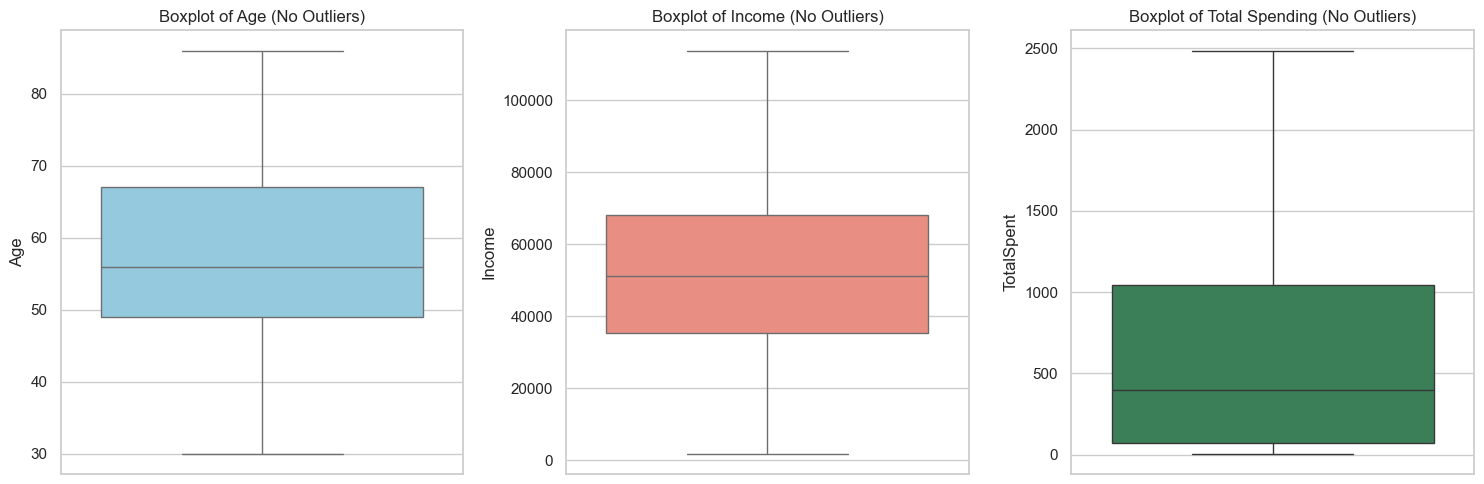

In [25]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_no_outliers["Age"], color="skyblue")
plt.title("Boxplot of Age (No Outliers)")

plt.subplot(1, 3, 2)
sns.boxplot(y=df_no_outliers["Income"], color="salmon")
plt.title("Boxplot of Income (No Outliers)")

plt.subplot(1, 3, 3)
sns.boxplot(y=df_no_outliers["TotalSpent"], color="seagreen")
plt.title("Boxplot of Total Spending (No Outliers)")

plt.tight_layout()
plt.show()

Response value counts:
Response
0    1880
1     333
Name: count, dtype: int64

Percentages:
Response
0    84.95
1    15.05
Name: proportion, dtype: float64


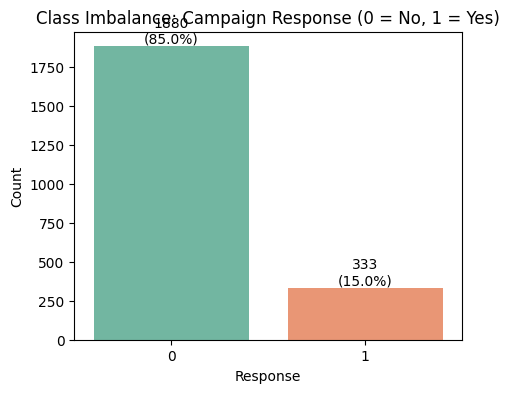

In [11]:
#Check and visualize class imbalance
# Count of each class
print("Response value counts:")
print(df["Response"].value_counts())
print("\nPercentages:")
print(df["Response"].value_counts(normalize=True).mul(100).round(2))

# Bar plot
plt.figure(figsize=(5, 4))
sns.countplot(
    data=df,
    x="Response",
    hue="Response",
    palette="Set2",
    legend=False
)
plt.title("Class Imbalance: Campaign Response (0 = No, 1 = Yes)")
plt.xlabel("Response")
plt.ylabel("Count")
for i, (count, pct) in enumerate(zip(
    df["Response"].value_counts().values,
    df["Response"].value_counts(normalize=True).mul(100).values
)):
    plt.text(i, count + 20, f"{count}\n({pct:.1f}%)", ha="center")
plt.show()

In [12]:
from imblearn.over_sampling import SMOTE

# Target ratio: minority (Yes) = 30% of total → ratio No:Yes ≈ 70:30
# sampling_strategy = 0.43 means Yes count = 0.43 * No count → ~30% Yes
smote = SMOTE(sampling_strategy=0.43, random_state=42)  # 0.43 ≈ 30/(100-30)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE (aim ~70% No, ~30% Yes):")
print(y_train_bal.value_counts(normalize=True).mul(100).round(2))

After SMOTE (aim ~70% No, ~30% Yes):
Response
0    69.95
1    30.05
Name: proportion, dtype: float64


Response value counts (after balancing):
Response
0    1504
1     646
Name: count, dtype: int64

Percentages (after balancing):
Response
0    69.95
1    30.05
Name: proportion, dtype: float64


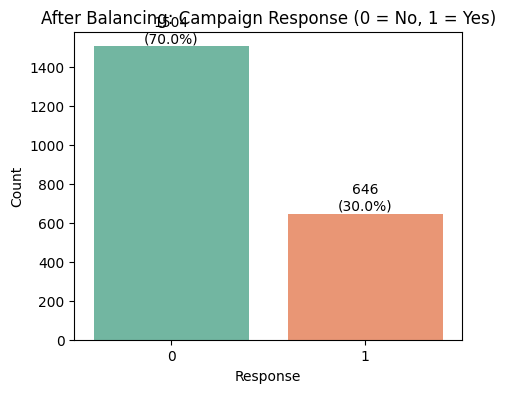

In [15]:
# Check and visualize class balance AFTER balancing (e.g. after SMOTE)

# Count of each class (use your balanced target variable)
y_bal = y_train_bal  # or whatever you named it after SMOTE fit_resample

print("Response value counts (after balancing):")
print(pd.Series(y_bal).value_counts())
print("\nPercentages (after balancing):")
print(pd.Series(y_bal).value_counts(normalize=True).mul(100).round(2))

# Bar plot for balanced data
df_bal_plot = pd.DataFrame({"Response": y_bal})

plt.figure(figsize=(5, 4))
sns.countplot(
    data=df_bal_plot,
    x="Response",
    hue="Response",
    palette="Set2",
    legend=False
)
plt.title("After Balancing: Campaign Response (0 = No, 1 = Yes)")
plt.xlabel("Response")
plt.ylabel("Count")

counts = pd.Series(y_bal).value_counts().values
pcts = pd.Series(y_bal).value_counts(normalize=True).mul(100).values
for i, (count, pct) in enumerate(zip(counts, pcts)):
    plt.text(i, count + 20, f"{count}\n({pct:.1f}%)", ha="center")

plt.show()

In [16]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# --- Handle class imbalance: aim for good balance (~70% No, ~30% Yes) ---

# Before balancing
print("Before balancing (train set):")
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True).mul(100).round(2))

# SMOTE: sampling_strategy=0.43 → minority (Yes) ≈ 30% of total (70% No, 30% Yes)
# For 50-50 use sampling_strategy=1
smote = SMOTE(sampling_strategy=0.43, random_state=42, k_neighbors=5)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# After balancing
print("\nAfter balancing (train set):")
print(pd.Series(y_train_balanced).value_counts())
print(pd.Series(y_train_balanced).value_counts(normalize=True).mul(100).round(2))

# Use these for training (test set stays unchanged)
# X_train_balanced, y_train_balanced  →  for model.fit()
# X_test_scaled, y_test               →  for model evaluation

Before balancing (train set):
Response
0    1504
1     266
Name: count, dtype: int64
Response
0    84.97
1    15.03
Name: proportion, dtype: float64

After balancing (train set):
Response
0    1504
1     646
Name: count, dtype: int64
Response
0    69.95
1    30.05
Name: proportion, dtype: float64


In [20]:
# Data preprocessing + scaling (single block)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

target = "Response"
df_ml = df.copy()

# Encode categoricals so all features are numeric
le_edu = LabelEncoder()
le_marital = LabelEncoder()
df_ml["Education"] = le_edu.fit_transform(df_ml["Education"].astype(str))
df_ml["Marital_Status"] = le_marital.fit_transform(df_ml["Marital_Status"].astype(str))

# Features and target
exclude = ["ID", "Dt_Customer", target]
feature_cols = [c for c in df_ml.columns if c not in exclude]
X = df_ml[feature_cols]
y = df_ml[target]

# Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

# Summary (one place)
print("Project: Analysing Customers Personality for Business Improvement using ML")
print("Preprocessing: LabelEncoder (Education, Marital_Status) + StandardScaler")
print("Features:", feature_cols)
print("Train size:", X_train_scaled.shape[0], "| Test size:", X_test_scaled.shape[0])
print("Target (train):", pd.Series(y_train).value_counts().to_dict())
print("Scaled train - mean (first 5):", X_train_scaled.iloc[:, :5].mean().round(4).to_dict())
print("Scaled train - std  (first 5):", X_train_scaled.iloc[:, :5].std().round(4).to_dict())

Project: Analysing Customers Personality for Business Improvement using ML
Preprocessing: LabelEncoder (Education, Marital_Status) + StandardScaler
Features: ['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Age', 'TotalSpent']
Train size: 1770 | Test size: 443
Target (train): {0: 1504, 1: 266}
Scaled train - mean (first 5): {'Year_Birth': -0.0, 'Education': 0.0, 'Marital_Status': 0.0, 'Income': -0.0, 'Kidhome': 0.0}
Scaled train - std  (first 5): {'Year_Birth': 1.0003, 'Education': 1.0003, 'Marital_Status': 1.0003, 'Income': 1.0003, 'Kidhome': 1.0003}


In [28]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 518.7 kB/s eta 0:03:16
   ---------------------------------------- 0.8/101.7 MB 686.2 kB/s eta 0:02:28
   ---------------------------------------- 1.0/101.7 MB 756.8 kB/s eta 0:02:13
   ---------------------------------------- 1.0/101.7 MB 756.8 kB/s eta 0:02:13
    --------------------------------------- 1.3/101.7 MB 723.6 kB/s eta 0:02:19
    --------------------------------------- 1.3/101.7 MB 723.6 kB/s eta 0:02:19
    --------------------------------------- 1.6/101.7 MB 751.9 kB/s eta 0:02:14
    --------------------------------------- 1.8/101.7 MB 759.0 kB/s eta 0:02:12
    --------------------------------------- 2.1/101.7 MB 788.7 kB/s eta 0:0

In [33]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost classifier
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,S
    eval_metric="logloss"
)
xgb_model.fit(X_tr, y_tr)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("=" * 60)
print("XGBOOST")
print("=" * 60)
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=["No", "Yes"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

C:\Users\satee\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST
Accuracy: 0.8736

Classification Report:
               precision    recall  f1-score   support

          No       0.89      0.97      0.93       376
         Yes       0.66      0.34      0.45        67

    accuracy                           0.87       443
   macro avg       0.77      0.66      0.69       443
weighted avg       0.86      0.87      0.86       443

Confusion Matrix:
 [[364  12]
 [ 44  23]]


In [33]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# XGBoost classifier
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,S
    eval_metric="logloss"
)
xgb_model.fit(X_tr, y_tr)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("=" * 60)
print("XGBOOST")
print("=" * 60)
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=["No", "Yes"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

C:\Users\satee\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:13:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBOOST
Accuracy: 0.8736

Classification Report:
               precision    recall  f1-score   support

          No       0.89      0.97      0.93       376
         Yes       0.66      0.34      0.45        67

    accuracy                           0.87       443
   macro avg       0.77      0.66      0.69       443
weighted avg       0.86      0.87      0.86       443

Confusion Matrix:
 [[364  12]
 [ 44  23]]


In [30]:
import pandas as pd

# If you still have y_pred_lr and y_pred_dt from earlier
print(pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "XGBoost"],
    "Accuracy": [
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_dt), 4),
        round(accuracy_score(y_test, y_pred_xgb), 4)
    ]
}))

                 Model  Accuracy
0  Logistic Regression    0.8668
1        Decision Tree    0.8330
2              XGBoost    0.8736


In [1]:
# ===================== FULL PIPELINE WITH TUNED XGBOOST =====================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
import xgboost as xgb

# 1) Load & basic cleaning
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.dropna(subset=["Income"])

numeric_cols = [
    "Year_Birth", "Income", "Kidhome", "Teenhome", "Recency",
    "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "NumDealsPurchases",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "AcceptedCmp1", "AcceptedCmp2",
    "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Complain",
    "Z_CostContact", "Z_Revenue", "Response"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df[numeric_cols] = df[numeric_cols].fillna(0)

df["Age"] = 2026 - df["Year_Birth"]
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["TotalSpent"] = df[spend_cols].sum(axis=1)
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]
df = df[df["Income"] > 0]

# 2) Encode categoricals & build X, y
target = "Response"
df_ml = df.copy()
df_ml["Education"] = LabelEncoder().fit_transform(df_ml["Education"].astype(str))
df_ml["Marital_Status"] = LabelEncoder().fit_transform(df_ml["Marital_Status"].astype(str))

exclude = ["ID", "Dt_Customer", target]
feature_cols = [c for c in df_ml.columns if c not in exclude]
X = df_ml[feature_cols]
y = df_ml[target]

# 3) Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5) SMOTE (better class balance ~70/30)
smote = SMOTE(sampling_strategy=0.43, random_state=42, k_neighbors=5)
X_tr, y_tr = smote.fit_resample(X_train_scaled, y_train)

print("Train size after SMOTE:", X_tr.shape[0], "| Test size:", X_test_scaled.shape[0])
print("Train class distribution:", pd.Series(y_tr).value_counts(normalize=True).mul(100).round(2).to_dict())

# 6) Base XGBoost + hyperparameter tuning
xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    nthread=-1
)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.2]
}

rand_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,          # increase for more search (slower)
    scoring="accuracy",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rand_search.fit(X_tr, y_tr)

print("\nBest CV accuracy:", rand_search.best_score_)
print("Best params:", rand_search.best_params_)

# 7) Evaluate best model on test set
best_xgb = rand_search.best_estimator_
y_pred_xgb_best = best_xgb.predict(X_test_scaled)

print("\n" + "="*60)
print("TUNED XGBOOST (best model)")
print("="*60)
test_acc = accuracy_score(y_test, y_pred_xgb_best)
print("Test Accuracy:", round(test_acc, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_best, target_names=["No", "Yes"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_best))

Train size after SMOTE: 2150 | Test size: 443
Train class distribution: {0: 69.95, 1: 30.05}
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best CV accuracy: 0.9074654116962618
Best params: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

TUNED XGBOOST (best model)
Test Accuracy: 0.8736

Classification Report:
               precision    recall  f1-score   support

          No       0.89      0.97      0.93       376
         Yes       0.67      0.33      0.44        67

    accuracy                           0.87       443
   macro avg       0.78      0.65      0.68       443
weighted avg       0.86      0.87      0.85       443

Confusion Matrix:
 [[365  11]
 [ 45  22]]


In [25]:
%pip install --upgrade pip setuptools wheel
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2: Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import xgboost as xgb
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

# Optional XAI lib
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False

In [3]:
# Cell 3: Load + Basic Cleaning
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Keep only rows with target
df = df.dropna(subset=["Response"]).copy()

# Handle missing income
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")
df["Income"] = df["Income"].fillna(df["Income"].median())

# Parse date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y", errors="coerce")
df["Dt_Customer"] = df["Dt_Customer"].fillna(df["Dt_Customer"].mode()[0])

# Feature engineering
current_date = df["Dt_Customer"].max()
df["Customer_Days"] = (current_date - df["Dt_Customer"]).dt.days
df["Age"] = 2026 - df["Year_Birth"]  # based on your current year context

# Remove constant / non-useful columns if present
for col in ["Z_CostContact", "Z_Revenue"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

print("Data shape:", df.shape)
df.head(3)

Data shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Days,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,1,663,69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,0,113,72
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,0,312,61


In [4]:
# Cell 4: Prepare data for prediction
target_col = "Response"

# Preserve ID for UI lookup
id_col = "ID"

# Model features
feature_df = df.drop(columns=[target_col]).copy()

# One-hot encode categorical columns
cat_cols = feature_df.select_dtypes(include=["object"]).columns.tolist()
feature_df = pd.get_dummies(feature_df, columns=cat_cols, drop_first=True)

# Ensure no datetime remains
for c in feature_df.columns:
    if np.issubdtype(feature_df[c].dtype, np.datetime64):
        feature_df[c] = feature_df[c].view("int64")

# Target
y = df[target_col].astype(int).values
X = feature_df.copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost
xgb_model = xgb.XGBClassifier(
    random_state=42,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

# Evaluate
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["No", "Yes"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.8906
ROC-AUC  : 0.9041

Classification Report:
               precision    recall  f1-score   support

          No       0.91      0.97      0.94       381
         Yes       0.71      0.45      0.55        67

    accuracy                           0.89       448
   macro avg       0.81      0.71      0.74       448
weighted avg       0.88      0.89      0.88       448

Confusion Matrix:
 [[369  12]
 [ 37  30]]


In [5]:
# Cell 5: Customer Segmentation (KMeans)
seg_cols = [
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "NumWebVisitsMonth", "Income"
]

seg_data = df[seg_cols].copy()
seg_scaler = StandardScaler()
seg_scaled = seg_scaler.fit_transform(seg_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(seg_scaled)

segment_names = {
    0: "Segment 0 - Moderate Buyers",
    1: "Segment 1 - High Value Customers",
    2: "Segment 2 - Low Engagement Customers"
}
df["Segment_Name"] = df["Segment"].map(segment_names)

print(df["Segment_Name"].value_counts())

Segment_Name
Segment 0 - Moderate Buyers             1088
Segment 2 - Low Engagement Customers     621
Segment 1 - High Value Customers         531
Name: count, dtype: int64


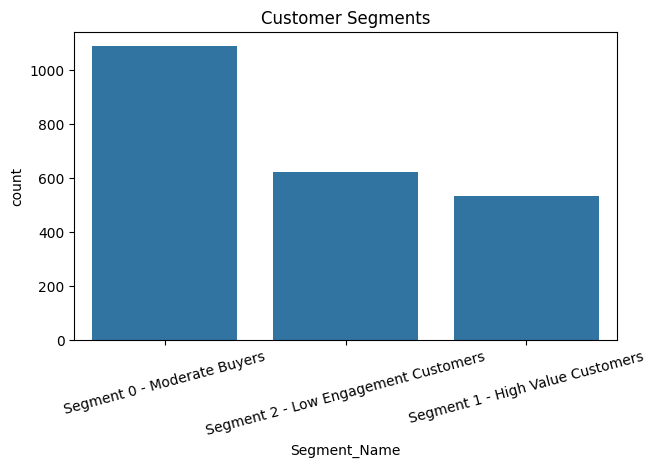

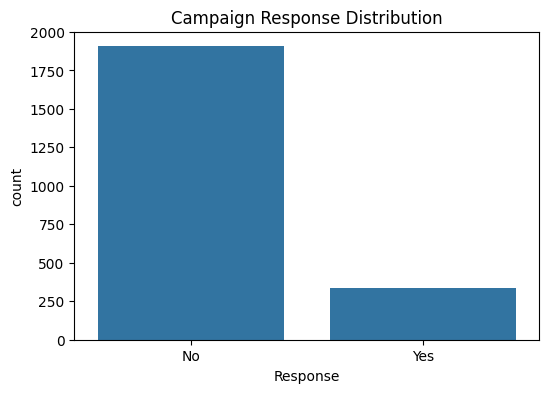

In [6]:
# Cell 6: Simple charts (optional)
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Segment_Name", order=df["Segment_Name"].value_counts().index)
plt.title("Customer Segments")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Response")
plt.title("Campaign Response Distribution")
plt.xticks([0,1], ["No", "Yes"])
plt.show()

In [7]:
# Cell 7 (REPLACE with this): Prepare full prediction table (for UI use)

X_full = df.drop(columns=["Response"]).copy()

# Convert datetime -> numeric (int64 nanoseconds)
if "Dt_Customer" in X_full.columns:
    X_full["Dt_Customer"] = pd.to_datetime(X_full["Dt_Customer"], errors="coerce")
    X_full["Dt_Customer"] = X_full["Dt_Customer"].view("int64")  # numeric

# One-hot encode categoricals
X_full = pd.get_dummies(X_full, drop_first=True)

# Add any missing training columns
for c in X_train.columns:
    if c not in X_full.columns:
        X_full[c] = 0

# Keep same column order as training
X_full = X_full[X_train.columns]

df["Pred_Prob_Response_Yes"] = xgb_model.predict_proba(X_full)[:, 1]
df["Pred_Response"] = (df["Pred_Prob_Response_Yes"] >= 0.5).astype(int).map({0: "No", 1: "Yes"})



In [8]:
# Cell 8: XAI helper
# If SHAP is available, use local explanation. Otherwise show top global features.
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_full)
else:
    global_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

In [9]:
# Colorful full-width UI (Jupyter Notebook)

import ipywidgets as widgets
from IPython.display import display, HTML, clear_output, Markdown

# --- Style (colors + bigger layout) ---
display(HTML("""
<style>
.big-app {
  width: 100% !important;
  max-width: 1200px;
  margin: 0 auto;
  padding: 18px 22px;
  background: linear-gradient(135deg, #0ea5e9 0%, #6366f1 45%, #ec4899 100%);
  border-radius: 18px;
  box-shadow: 0 18px 45px rgba(0,0,0,0.25);
  color: white;
  font-family: Arial, sans-serif;
}

.big-title {
  font-size: 34px;
  font-weight: 800;
  margin: 0 0 6px 0;
}

.big-subtitle {
  font-size: 16px;
  opacity: 0.95;
  margin: 0 0 16px 0;
}

.card-row {
  display: grid;
  grid-template-columns: 1fr 1fr 1fr;
  gap: 14px;
  margin-top: 14px;
}

.card {
  background: rgba(255,255,255,0.14);
  border: 1px solid rgba(255,255,255,0.25);
  border-radius: 14px;
  padding: 14px 14px;
}

.card h3 {
  margin: 0 0 8px 0;
  font-size: 16px;
}

.kpi {
  font-size: 30px;
  font-weight: 900;
  margin: 0;
}

.small {
  margin: 4px 0 0 0;
  opacity: 0.95;
  font-size: 13px;
}

hr.soft {
  border: 0;
  height: 1px;
  background: rgba(255,255,255,0.28);
  margin: 14px 0;
}

.xai-list li{
  margin-bottom: 6px;
  font-size: 14px;
}
</style>
"""))

# --- Widgets (bigger) ---
title_html = widgets.HTML("""
<div class="big-app">
  <div class="big-title">🎯 FINAL OUTPUT OF YOUR PROJECT</div>
  <div class="big-subtitle">
    Predict campaign response (Yes/No) • Segment customers • Explain why (XAI)
  </div>
</div>
""")

id_dropdown = widgets.Dropdown(
    options=sorted(df["ID"].unique().tolist()),
    description="Customer ID",
    layout=widgets.Layout(width="420px"),
    style={"description_width": "110px"}
)

threshold_slider = widgets.FloatSlider(
    value=0.50, min=0.05, max=0.95, step=0.05,
    description="Threshold",
    readout_format=".2f",
    layout=widgets.Layout(width="420px"),
    style={"description_width": "110px"}
)

run_btn = widgets.Button(
    description="Analyze",
    button_style="success",
    layout=widgets.Layout(width="180px", height="42px")
)

controls = widgets.HBox(
    [id_dropdown, threshold_slider, run_btn],
    layout=widgets.Layout(justify_content="space-between", width="100%", max_width="1200px", margin="10px auto 0 auto")
)

out = widgets.Output(layout=widgets.Layout(width="100%", max_width="1200px", margin="10px auto 0 auto"))

def analyze_customer(_):
    with out:
        clear_output()

        cid = id_dropdown.value
        thr = threshold_slider.value

        row = df[df["ID"] == cid].iloc[0]
        row_idx = df[df["ID"] == cid].index[0]

        prob = float(row["Pred_Prob_Response_Yes"])
        pred = "Yes" if prob >= thr else "No"
        seg = row["Segment_Name"]

        # XAI
        xai_html = ""
        if SHAP_AVAILABLE:
            contrib = pd.Series(shap_values[row_idx], index=X_full.columns)
            top_pos = contrib.sort_values(ascending=False).head(4)
            top_neg = contrib.sort_values(ascending=True).head(4)

            pos_items = "".join([f"<li><b>{f}</b> : {v:.4f}</li>" for f, v in top_pos.items()])
            neg_items = "".join([f"<li><b>{f}</b> : {v:.4f}</li>" for f, v in top_neg.items()])

            xai_html = f"""
            <div class="card">
              <h3>🔎 Why this prediction? (XAI)</h3>
              <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px;">
                <div>
                  <div style="font-weight:700;margin-bottom:6px;">Top positive factors</div>
                  <ul class="xai-list">{pos_items}</ul>
                </div>
                <div>
                  <div style="font-weight:700;margin-bottom:6px;">Top negative factors</div>
                  <ul class="xai-list">{neg_items}</ul>
                </div>
              </div>
            </div>
            """
        else:
            top = global_importance.head(8)
            items = "".join([f"<li><b>{f}</b> (importance: {v:.4f})</li>" for f, v in top.items()])
            xai_html = f"""
            <div class="card">
              <h3>🔎 Why this prediction? (XAI)</h3>
              <div class="small"><b>Note:</b> Install <code>shap</code> for per-customer explanations.</div>
              <ul class="xai-list">{items}</ul>
            </div>
            """

        display(HTML(f"""
        <div class="big-app">
          <div style="display:flex;justify-content:space-between;align-items:flex-end;gap:10px;flex-wrap:wrap;">
            <div>
              <div style="font-size:20px;font-weight:800;">Customer ID: {cid}</div>
              <div class="small">Model: XGBoost • Threshold: {thr:.2f}</div>
            </div>
            <div style="font-size:13px;opacity:0.95;">
              Tip: change threshold to target fewer/more customers
            </div>
          </div>

          <hr class="soft"/>

          <div class="card-row">
            <div class="card">
              <h3>✅ Predicted Response</h3>
              <p class="kpi">{pred}</p>
              <p class="small">Yes if probability ≥ threshold</p>
            </div>

            <div class="card">
              <h3>📈 Probability (Yes)</h3>
              <p class="kpi">{prob*100:.1f}%</p>
              <p class="small">Higher means more likely to respond</p>
            </div>

            <div class="card">
              <h3>👥 Segment</h3>
              <p class="kpi" style="font-size:18px;line-height:1.2;">{seg}</p>
              <p class="small">Based on spending + behavior</p>
            </div>
          </div>

          <hr class="soft"/>

          {xai_html}
        </div>
        """))

run_btn.on_click(analyze_customer)

display(title_html, controls, out)

HTML(value='\n<div class="big-app">\n  <div class="big-title">🎯 FINAL OUTPUT OF YOUR PROJECT</div>\n  <div cla…

Output(layout=Layout(margin='10px auto 0 auto', max_width='1200px', width='100%'))